# 원본 노트북 링크:
- https://github.com/bcaitech1/p4-fr-sorry-math-but-love-you/tree/master

In [6]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import os

os.chdir('/content/drive/MyDrive/Colab Notebooks/프로젝트/2025 한양대 졸업프로젝트 HMER/OMRiDA 2')

# Utils

- 그동안 imshow할때 aspect="auto"로 했어서 resize shape 관계없이 무조건 정방이미지로 시각화되었는데, resize 어떻게 되었는지 확인할 수 있게 aspect="equal"로 수정하고, 리사이즈 형상에 따라 성능영향차이가 생기는지 실험해보고자 함

In [9]:
import matplotlib.pyplot as plt

def plot_dataset(images, labels, grid_width, grid_height, figure_width, figure_height, y_hats=None, vocab=None, wspace=0.5, hspace=1):

  # images, labels는 torch.tensor 타입으로 들어온다고 가정

  f, ax = plt.subplots(grid_height, grid_width, squeeze=False)
  f.set_size_inches(figure_width, figure_height)
  img_idx = 0

  eos_idx = 1

  for i in range(0, grid_height):
    for j in range(0, grid_width):
      image = images[img_idx].cpu().detach()
      label = labels[img_idx].cpu().detach()
      title_color = 'k'

      assert vocab is not None, "vocab을 입력하세요"

      label = label.tolist()
      label = label[1:label.index(eos_idx)]     # <sos>, <eos> 부분 제외 (EOS_IDX == 2) - <eos> 이전까지 뽑아서 <eos>이후 <pad> 부분도 제외되도록
      label = vocab.decode(label)               # list -> str

      if y_hats is not None:
            y_hat = y_hats[img_idx].cpu().detach().tolist()

            if eos_idx in y_hat:
                y_hat = y_hat[:y_hat.index(eos_idx)]   # <eos> 존재하면 <eos> 이후부분 (<eos> 및 <pad>) 무시

            y_hat = vocab.decode(y_hat)         # list -> str


            if label != y_hat:
                title_color = 'r'

            label = f'gt: {label}\npred:{y_hat}'

      ax[i][j].axis('off')
      ax[i][j].set_title(label, color=title_color)
      ax[i][j].imshow(image.permute(1,2,0).numpy(), aspect='equal', cmap='gray')
      img_idx += 1

    plt.subplots_adjust(left=0, bottom=0, right=2, top=2, wspace=wspace, hspace=hspace)
  plt.show()

In [10]:
import editdistance

def exprate_k(preds, targets, k=0, eos_idx=1):

    # preds, targets에는 <sos>가 제거된 채로 함수인자로 들어온다고 가정

    # preds: (B, T-1)
    # targets: (B, T-1)

    assert preds.shape[0] == targets.shape[0], "예측 label과 정답 label의 배치 크기가 다릅니다"

    cnt = 0
    for pred_seq, tgt_seq in zip(preds, targets):

        pred = pred_seq.tolist()
        tgt = tgt_seq.tolist()

        if eos_idx in pred:
            pred = pred[:pred.index(eos_idx)]

        if eos_idx in tgt:
            tgt = tgt[:tgt.index(eos_idx)]

        diff = editdistance.eval(pred, tgt)

        if diff<=k:
            cnt += 1

    return cnt / preds.shape[0]


def WER(preds, targets, eos_idx=1):

    # preds, targets에는 <sos>가 제거된 채로 함수인자로 들어온다고 가정

    # preds: (B, T-1)
    # targets: (B, T-1)

    assert preds.shape[0] == targets.shape[0], "예측 label과 정답 label의 배치 크기가 다릅니다"

    sum_wer = 0.0
    for pred_seq, tgt_seq in zip(preds, targets):

        pred = pred_seq.tolist()
        tgt = tgt_seq.tolist()

        if eos_idx in pred:
            pred = pred[:pred.index(eos_idx)]

        if eos_idx in tgt:
            tgt = tgt[:tgt.index(eos_idx)]

        distance = editdistance.eval(pred, tgt)
        length = len(tgt)

        sum_wer += (distance/length)

    return sum_wer / preds.shape[0]

In [11]:
import os
import json
from pathlib import Path

def save_log(log_dict, save_path="log.json"):

    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    with open(save_path, "w", encoding="utf-8") as f:
        json.dump(log_dict, f, indent=2)
    print(f"저장 완료: {save_path}")


def plot_loss_curve(log_dict, metric="loss", overlap=False):

    assert metric in ["loss", "expr@0", "expr@1", "expr@2", "expr@3", "wer"], "metric은 loss, expr@0, expr@2, expr@3, wer 중 선택하여 입력해야합니다"

    if overlap==False:
        fig, axes = plt.subplots(2,1)

        fig.suptitle(f"{metric} Curve")

        # train
        train = log_dict["Train"]
        epochs = range(1, len(train)+1)

        train_metric = []
        for log in train:
            train_metric.append(log[metric])

        axes[0].plot(epochs, train_metric, marker='o')
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel(f"train {metric}")
        axes[0].grid(True)


        # valid
        valid = log_dict["Valid"]
        epochs = range(1, len(valid)+1)

        valid_metric = []
        for log in valid:
            valid_metric.append(log[metric])

        axes[1].plot(epochs, valid_metric, marker='o')
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel(f"valid {metric}")
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

    else:

        # train
        train = log_dict["Train"]
        epochs = range(1, len(train)+1)

        train_metric = []
        for log in train:
            train_metric.append(log[metric])

        plt.plot(epochs, train_metric, marker='o', label=f"Train {metric}")


        # valid
        valid = log_dict["Valid"]
        epochs = range(1, len(valid)+1)

        valid_metric = []
        for log in valid:
            valid_metric.append(log[metric])

        plt.plot(epochs, valid_metric, marker='o', label=f"Valid {metric}")

        plt.xlabel("Epoch")
        plt.ylabel(f"{metric}")
        plt.title(f"{metric} Curve")

        plt.legend()
        plt.grid(True)
        plt.show()

In [12]:
import gspread

def save_test_result(experiment_name, val_dict):
    """ 실험결과를 구글스프레드시트에 저장 """

    gc = gspread.service_account(filename="service_account.json")
    sh = gc.open("test_results")

    # experiment_name이 스프레드시트의 각 sheet (윈도우)에 존재하는지 확인
    for metric in ["loss", "expr@0", "expr@1", "expr@2", "expr@3", "wer"]:
        worksheet = sh.worksheet(metric)

        try:
            row = worksheet.find(experiment_name).row

            # 이미 해당 실험이 과거에 진행된 경우가 있어 값들이 채워져있다면, 새로 실험하는 것이므로 해당 실험의 이전값들을 모든 sheet (윈도우)에 대해서 초기화해주고 시작
            range = f"B{row}:I{row}"
            val = [[""] * 8]
            worksheet.batch_update([{
                "range": range,
                "values": val
            }])

        except:
            last_row = len(worksheet.col_values(1))  # A열 중 값이 채워진 부분의 마지막 행번호
            worksheet.update_cell(last_row+1, 1, experiment_name)

    for metric in val_dict.keys():
        worksheet = sh.worksheet(metric)
        row = worksheet.find(experiment_name).row

        range = f"B{row}:I{row}"
        worksheet.batch_update([{
            "range": range,
            "values": [val_dict[metric]]
        }])

# Config (Global Parameters)
- 변경사항: optimizer 옵션을 config에 추가, weight_decay 적용

In [13]:

import torch
DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(DEVICE)

cuda


In [44]:
import os, json
from datetime import datetime
import torch

epoch = int(input("epoch: "))
patience = int(input("patience: "))
bs = int(input("batch size: "))
optimizer_name = input("optimizer name (AdamW, adadelta, ...): ")

CFG = {
  "img_size": (256,1024),
  "pad_idx": 112,
  "sos_idx": 0,
  "eos_idx": 1,

  "data": {
    "crohme": {
      "hme_img": "data/preprocessed/train/paired/crohme/hme_preprocessed",
      "pme_img": "data/preprocessed/train/paired/crohme/pme_preprocessed",
      "caption": "data/preprocessed/train/paired/crohme/caption.txt",
    },
    "im2latex": {
      "hme_img": "data/preprocessed/train/paired/im2latex/hme_img_train",
      "pme_img": "data/preprocessed/train/paired/im2latex/pme_img_train",
      "caption": "data/preprocessed/train/paired/im2latex/caption_train.txt",
    },
  },

  "model": {
    "vocab_size": 112,
    "encoder_emb_dim": 256,
    "decoder_emb_dim": 256,
    "decoder_hidden_dim": 512
  },

  "training": {
    "batch_size": bs,
    "epochs": epoch,
    "learning_rate": 0.001,   # 사실상 CosineAnnealingWarmupRestarts사용하면 이 부분의 학습률은 적용 안되는 셈임
    "match_weight": 0.2,      # DWAP에는 사용되지 않는 파라미터
    "optimizer": optimizer_name,
    "weight_decay": 1e-4,
    "grad_clip": 1.0,
    "tf_ratio": 0.5,
    "early_stop_patience": patience,
  },

  "testing": {"max_len": 150}
}

model_name = "NAVER winner (Efficient ASTER) - 256x1024 resize, 3 channels"
scheduler_name = input("scheduler_name (CircularLRBeta, CosineAnnealingWarmup, ...): ")
min_lr = float(input("min_lr: "))
max_lr = float(input("max_lr: "))

experiment_name = f"{model_name}_epoch{CFG['training']['epochs']}_patience_{CFG['training']['early_stop_patience']}_bs{CFG['training']['batch_size']}_scheduler_{scheduler_name}_minLR_{min_lr}_maxLR_{max_lr}"

CFG["experiment_name"] = experiment_name

paths = {}
paths["best_ckpt"] = f"runs/{experiment_name}/best_model.pth"
paths["last_ckpt"] = f"runs/{experiment_name}/last_model.pth"
paths["train_log_json"] = f"runs/{experiment_name}/train_log.json"
paths["CFG"] = f"runs/{experiment_name}/config.json"

CFG["paths"] = paths

scheduler_info = {"name": scheduler_name}

CFG["scheduler"] = scheduler_info

epoch: 20
patience: 3
batch size: 16
optimizer name (AdamW, adadelta, ...): adamw
scheduler_name (CircularLRBeta, CosineAnnealingWarmup, ...): circularlrbeta
min_lr: 5e-4
max_lr: 5e-4


In [45]:
# 실험환경 디테일 config 저장

save_log(CFG, CFG["paths"]["CFG"])

저장 완료: runs/NAVER winner (Efficient ASTER) - 256x1024 resize, 3 channels_epoch20_patience_3_bs16_scheduler_circularlrbeta_minLR_0.0005_maxLR_0.0005/config.json


In [46]:
# 실험환경 폴더 생성

Path(os.path.join("runs", CFG["experiment_name"])).mkdir(parents=True, exist_ok=True)

# Custom Dataset

## Vocab

In [38]:
# IM2LATEX 캡션 전처리용
def tokenize_formula(formula):
    ans = []
    tokens = formula.strip().split()

    for tok in tokens:
        chk = 0
        for sym in ["cm", "mm", "pt", "in", "ex", "em"]:
            if (tok[-2:] == sym) and tok[-3].isdigit():
                num, _ = tok.split(sym)
                num = ' '.join(num).split()
                ans.extend(num)
                ans.append(sym)
                chk = 1
                break

        if chk == 0:
            ans.append(tok)
    return ans


from typing import List

class Vocab:
  SOS_TOKEN = "<sos>"
  EOS_TOKEN = "<eos>"

  def __init__(self):
    self.default_tokens = [self.SOS_TOKEN, self.EOS_TOKEN]
    self.token2idx = {tok: idx for idx, tok in enumerate(self.default_tokens)}
    self.idx2token = self.default_tokens.copy()

  def __len__(self):
    return len(self.idx2token)

  def load_from_txt(self, path):
    with open(path, "r", encoding="latin1") as f:
      for line in f:
        token = line.strip()
        if token not in self.token2idx:
          idx = len(self.token2idx)
          self.token2idx[token] = idx
          self.idx2token.append(token)

  def encode(self, caption: str) -> List[int]:
    tokens = tokenize_formula(caption)
    return [self.token2idx[self.SOS_TOKEN]] + \
           [self.token2idx[token] for token in tokens] + \
           [self.token2idx[self.EOS_TOKEN]]

  def decode(self, token_ids: List[int]) -> str:
    return ' '.join([self.idx2token[token_id] for token_id in token_ids])

vocab = Vocab()
vocab.load_from_txt("vocab.txt")

In [39]:
from torchvision import transforms
import torch
from PIL import ImageOps

def formula_collate_fn(batch):
    images = torch.stack([item["image"] for item in batch], dim=0)
    formulas = torch.nn.utils.rnn.pad_sequence(
        [item["formula"] for item in batch],
        batch_first=True,
        padding_value=CFG["pad_idx"]
    )
    return {"image": images, "formula": formulas}

In [40]:
from pathlib import Path
from torch.utils.data import Dataset
from PIL import Image
import torch


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(CFG["img_size"]),
    transforms.Normalize(mean=[0.5], std=[0.5]),]
)


class FormulaDataset(Dataset):
  def __init__(self, img_path, labels_path, transform, vocab):
    self.img_path = img_path
    self.labels_path = labels_path
    self.transform = transform
    self.vocab = vocab

    self.samples = []
    with open(labels_path, "r", encoding="utf-8") as f:
      for line in f:
        parts = line.strip().split('\t')
        if len(parts)!=2:
          continue
        file_id, caption = parts

        if '.' not in file_id:
          file_id = f"{file_id}.png"

        img_path = os.path.join(self.img_path, file_id)
        if os.path.exists(img_path):
          self.samples.append((img_path, caption))

  def __len__(self):
    return len(self.samples)

  def __getitem__(self, idx):
    img_path, caption = self.samples[idx]
    img = Image.open(img_path).convert('RGB')#.convert('L')

    if self.transform:
      img = self.transform(img)

    caption_tokens = self.vocab.encode(caption)
    caption = torch.tensor(caption_tokens)

    return {"image": img, "formula": caption}

In [41]:
train_path = CFG["data"]["crohme"]["hme_img"]
train_labels_path = CFG["data"]["crohme"]["caption"]

years = [2014, 2016, 2019]
crohme_test_paths = [f"data/preprocessed/test/hme/crohme/{year}/hme_img_preprocessed" for year in years]
crohme_test_labels_paths = [f"data/preprocessed/test/hme/crohme/{year}/caption.txt" for year in years]

cropme_test_paths = [f"data/preprocessed/test/pme/crohme/{year}/pme_img" for year in years]
cropme_test_labels_paths = [f"data/preprocessed/test/pme/crohme/{year}/caption.txt" for year in years]

im2latex_pme_path = "data/preprocessed/test/pme/im2latex/pme_img_test"
im2latex_pme_labels_path = "data/preprocessed/test/pme/im2latex/caption_test.txt"

im2latex_hme_path = "data/preprocessed/test/hme/im2latex/hme_img_test"
im2latex_hme_labels_path = "data/preprocessed/test/hme/im2latex/caption_test.txt"

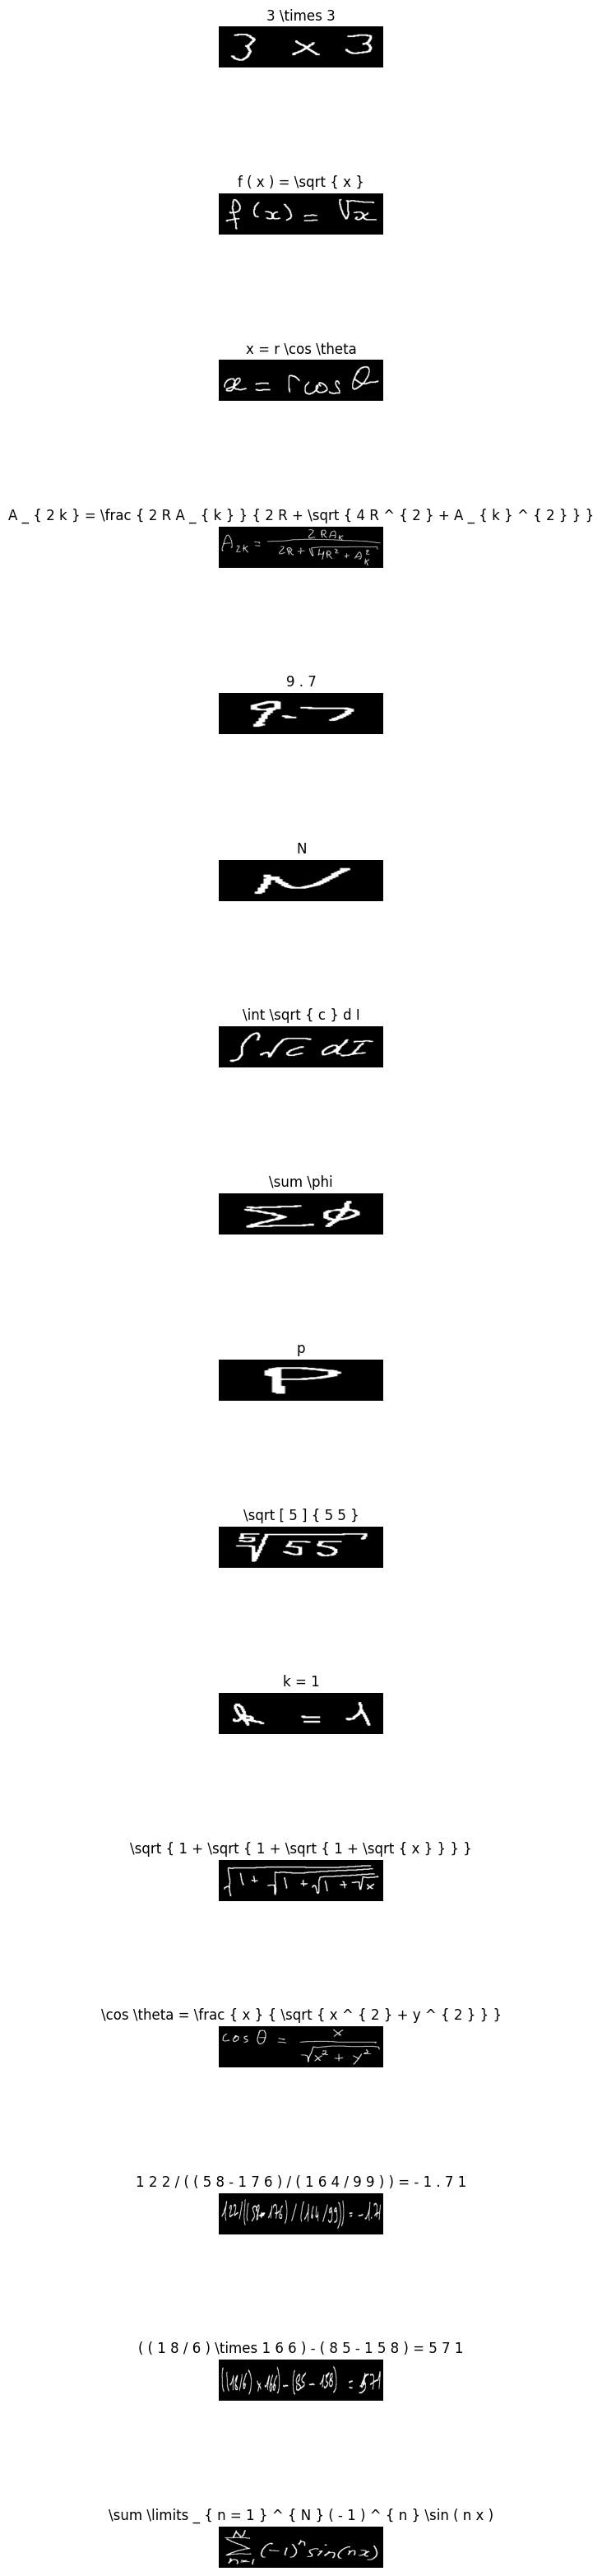

In [42]:
batch_size = CFG["training"]["batch_size"]


# train valid split
trainset = FormulaDataset(train_path, train_labels_path, transform, vocab)
train_size = int(0.8 * len(trainset))
valid_size = len(trainset) - train_size
trainset, validset = torch.utils.data.random_split(trainset,[train_size, valid_size])


# loader

# train, valid
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True, collate_fn=formula_collate_fn
)
validloader = torch.utils.data.DataLoader(
    validset, batch_size=1, shuffle=False, collate_fn=formula_collate_fn
)

# test - CROHME
crohme_testset_2014 = FormulaDataset(crohme_test_paths[0], crohme_test_labels_paths[0], transform, vocab)
crohme_testset_2016 = FormulaDataset(crohme_test_paths[1], crohme_test_labels_paths[1], transform, vocab)
crohme_testset_2019 = FormulaDataset(crohme_test_paths[2], crohme_test_labels_paths[2], transform, vocab)

crohme_testloader_2014 = torch.utils.data.DataLoader(
    crohme_testset_2014, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

crohme_testloader_2016 = torch.utils.data.DataLoader(
    crohme_testset_2016, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

crohme_testloader_2019 = torch.utils.data.DataLoader(
    crohme_testset_2019, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

# test - CROPME
cropme_testset_2014 = FormulaDataset(cropme_test_paths[0], cropme_test_labels_paths[0], transform, vocab)
cropme_testset_2016 = FormulaDataset(cropme_test_paths[1], cropme_test_labels_paths[1], transform, vocab)
cropme_testset_2019 = FormulaDataset(cropme_test_paths[2], cropme_test_labels_paths[2], transform, vocab)

cropme_testloader_2014 = torch.utils.data.DataLoader(
    cropme_testset_2014, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

cropme_testloader_2016 = torch.utils.data.DataLoader(
    cropme_testset_2016, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

cropme_testloader_2019 = torch.utils.data.DataLoader(
    cropme_testset_2019, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)


# test - IM2LATEX (vocab 통일한 IM2LATEX의 caption 중 7:3으로 훈련 테스트 데이터 나누어 별도로 저장하여 구성하였음)

im2latex_hme_testset = FormulaDataset(im2latex_hme_path, im2latex_hme_labels_path, transform, vocab)
im2latex_hme_testloader = torch.utils.data.DataLoader(
    im2latex_hme_testset, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

im2latex_pme_testset = FormulaDataset(im2latex_pme_path, im2latex_pme_labels_path, transform, vocab)
im2latex_pme_testloader = torch.utils.data.DataLoader(
    im2latex_pme_testset, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)


# 데이터 확인

batch = next(iter(trainloader))
images = batch['image']
labels = batch['formula']
plot_dataset(images, labels, grid_width=1, grid_height=bs, figure_width=1, figure_height=bs, vocab=vocab, wspace=0.25, hspace=0.25)

# MODEL

## EfficientASTER

In [22]:
import torch
from torch.utils.data import DataLoader
from queue import PriorityQueue


def decode(
    model,
    input: torch.Tensor,
    data_loader: DataLoader = None,
    expected: torch.Tensor = None,
    method: str = "greedy",
    beam_width: int = 3,
) -> torch.Tensor:
    """디코딩을 수행하는 함수. NOTE: inference/validation에만 활용!

    Args:
        model (torch.nn.Module):
        input (torch.Tensor): 이미지 input
        data_loader (DataLoader, optional):
            - Beam-Search를 활용할 경우 필요한 argument
            - Defaults to None.
        expected (torch.Tensor, optional):
            - Validation에서 디코딩할 경우 필요한 argument: Validation 단계에서는 max_length를 ground-truth를 바탕으로 설정하기 때문
            - Defaults to None.
        method (str, optional): 디코딩 타입 설정. Defaults to 'greedy'.
            - 'greedy': 그리디 디코딩
            - 'beam': 빔서치
        beam_width (int, optional): 빔서치 활용 시 채택할 beam size. Defaults to 3.

    Returns:
        squence (torch.Tensor): id_to_string에 입력 가능한 output sequence 텐서
    """

    if method == "greedy":
        output = model(
            input=input, expected=expected, is_train=False, teacher_forcing_ratio=0.0
        )
        decoded_values = output.transpose(1, 2)  # [B, VOCAB_SIZE, MAX_LEN]
        _, sequence = torch.topk(decoded_values, 1, dim=1)  # sequence: [B, 1, MAX_LEN]
        sequence = sequence.squeeze(1)  # [B, MAX_LEN], 각 샘플에 대해 시퀀스가 생성 상태

    elif method == "beam":
        sequence = model.beam_search(
            input=input,
            data_loader=data_loader,
            beam_width=beam_width,
            max_sequence=expected.size(-1) - 1,  # expected에는 이미 시작 토큰 개수까지 포함
        )

    else:
        raise NotImplementedError(f"There's no '{method}' type yet.")

    return sequence


class BeamSearchNode(object):
    def __init__(self, hidden_state, prev_node, token_id, log_prob, length):
        self.hidden_state = hidden_state
        self.prev_node = prev_node
        self.token_id = token_id
        self.logp = log_prob
        self.len = length  # 길이

    def eval(self, alpha=0.1) -> float:
        """score 측정 함수
        score: L - 해당 스텝까지의 총 길이, alpha - 페널티항, c: context
            {1/L^{alpha}} * log{ P(y_{1}, ..., y_{L} | c)}
            = {1/L^{alpha}}*SUM_{t'=1}^{L}{log{P(y_{1}, ..., y_{L} | c)}}
        Args:
            alpha (float, optional): 스텝 길이에 따른 페널티를 위한 파라미터. Defaults to 0.75.

        Returns:
            score (float): 점수

        References:
            - Beam Search, Dive into Deep Learning,
              https://d2l.ai/chapter_recurrent-modern/beam-search.html#id1
        """

        return self.logp / (float(self.len))  # **alpha)
        # return self.logp / float(self.len - 1 + 1e-6) + alpha * reward

    def __lt__(self, other):
        return self.len < other.len

    def __gt__(self, other):
        return self.len > other.len

    def get_penalty(self, length, alpha: float = 1.2, min_length: int = 5):
        p = ((1 + length) / (1 + min_length)) ** alpha
        return p

In [23]:
import sys
import math
import random
import operator
from queue import PriorityQueue
from copy import deepcopy
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
import torch.nn.functional as F
import timm
import sys

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class DeepCNN(nn.Module):
    def __init__(self, nc: int, leaky_relu=False):
        super(DeepCNN, self).__init__()
        m = timm.create_model("tf_efficientnetv2_s_in21ft1k", pretrained=True)
        self.conv_stem = nn.Conv2d(
            nc, 24, kernel_size=(3, 3), stride=(2, 2), bias=False
        )
        self.bn1 = nn.BatchNorm2d(
            24, eps=1e-3, momentum=0.1, affine=True, track_running_stats=True
        )
        self.act1 = nn.SiLU(inplace=True)
        self.eff_blocks = m.blocks
        self.pooling1 = nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 1), padding=(0, 1))
        self.conv1 = self.convRelu(nc, 4, leaky_relu=leaky_relu, bn=True)
        self.conv2 = self.convRelu(nc, 5, leaky_relu=leaky_relu)
        self.pooling2 = nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 1), padding=(0, 1))
        self.conv3 = self.convRelu(nc, 6, leaky_relu=leaky_relu, bn=True)

    def forward(self, input):
        out = self.conv_stem(input)  # [B, 24, 127, 511]
        out = self.bn1(out)  # [B, 24, 127, 511]
        out = self.act1(out)  # [B, 24, 127, 511]
        out = self.eff_blocks(out)  # [B, 256, 8, 32]
        out = self.pooling1(out)  # [B, 256, 4, 33]
        out = self.conv1(out)  # [B, 384, 4, 33]
        out = self.pooling2(out)  # [B, 384, 2, 34]
        out = self.conv3(out)  # [B, 384, 1, 33]
        return out

    @staticmethod
    def convRelu(nc, i, leaky_relu: bool, bn=False) -> nn.Module:
        """Conv 레이어를 생성하는 함수
        Args:
            i (int): ks, ps, ss, nm으로부터 가져올 element의 인덱스
            batchNormalization (bool, optional): BN 적용 여부. Defaults to False.
        """
        ks = [3, 3, 3, 3, 3, 3, 2]  # kernel size
        ps = [1, 1, 1, 1, 1, 1, 0]  # padding size
        ss = [1, 1, 1, 1, 1, 1, 1]  # strides
        # nm = [64, 128, 256, 256, 512, 512, 512]  # output channel list
        nm = [64, 128, 256, 256, 384, 384, 384]  # output channel list

        cnn = nn.Sequential()
        nIn = nc if i == 0 else nm[i - 1]
        nOut = nm[i]
        cnn.add_module("conv{0}".format(i), nn.Conv2d(nIn, nOut, ks[i], ss[i], ps[i]))
        if bn:
            cnn.add_module("batchnorm{0}".format(i), nn.BatchNorm2d(nOut))

        if leaky_relu:
            cnn.add_module("relu{0}".format(i), nn.LeakyReLU(0.2, inplace=True))
        else:
            cnn.add_module("relu{0}".format(i), nn.ReLU(True))

        return cnn


class AttentionCell(nn.Module):
    """디코더(ASTERDecoder) 내 Attention 계산에 활용할 attention cell 클래스"""

    def __init__(
        self,
        src_dim: int,
        hidden_dim: int,
        embedding_dim: int,
        num_layers=1,
    ):
        """
        Args:
            src_dim (int): 입력 데이터의 dim
            hidden_dim (int):
                - RNN 내에서 활용될 hidden state의 dim
            embedding_dim (int):
                - 입력 데이터의 임베딩 결과 dim
                - 입력 데이터가 RNN 레이어에 입력되기 전에 임베딩 과정을 거침
            num_layers (int, optional): RNN 레이어 수. Defaults to 1.
            cell_type (str, optional): RNN 모델 타입. Defaults to 'LSTM'
                - RNN의 input dim: src_dim + embedding_dim
        """
        super(AttentionCell, self).__init__()
        self.num_layers = num_layers

        self.i2h = nn.Linear(src_dim, hidden_dim, bias=False)  # input dim to hidden dim

        # hidden dim to hidden dim
        self.h2h = nn.Linear(
            hidden_dim, hidden_dim
        )  # either i2i or h2h should have bias <- why?
        self.score = nn.Linear(hidden_dim, 1, bias=False)  # to get attention logit

        if num_layers == 1:
            self.rnn = nn.LSTMCell(src_dim + embedding_dim, hidden_dim)
        else:
            self.rnn = nn.ModuleList(
                [nn.LSTMCell(src_dim + embedding_dim, hidden_dim)]
                + [nn.LSTMCell(hidden_dim, hidden_dim) for _ in range(num_layers - 1)]
            )
        self.hidden_dim = hidden_dim

    def forward(self, prev_hidden, src, tgt):  # src: [b, L, c]
        """
        input:
            prev_hidden (torch.Tensor): 이전 state에서의 hidden state. [b, h]
            src (torch.Tensor): X_t. [b, L, c]
            tgt (torch.Tensor): START 토큰 등 RNN의 입력으로 들어가는 텐서
        output:
        """
        src_features = self.i2h(src)  # [b, L, h]
        if self.num_layers == 1:
            prev_hidden_proj = self.h2h(prev_hidden[0]).unsqueeze(1)  # [b, 1, h]
        else:
            prev_hidden_proj = self.h2h(prev_hidden[-1][0]).unsqueeze(1)  # [b, 1, h]
        attention_logit = self.score(
            torch.tanh(src_features + prev_hidden_proj)  # [b, L, h]
        )  # [b, L, 1]
        alpha = F.softmax(attention_logit, dim=1)  # [b, L, 1]
        context = torch.bmm(alpha.permute(0, 2, 1), src).squeeze(
            1
        )  # [b, c], values applied attention

        concat_context = torch.cat([context, tgt], 1)  # [b, c+e]

        # cur_hidden: [hidden_state, cell_state] for LSTM
        if self.num_layers == 1:
            cur_hidden = self.rnn(concat_context, prev_hidden)
        else:
            cur_hidden = []
            for i, layer in enumerate(self.rnn):
                if i == 0:
                    concat_context = layer(concat_context, prev_hidden[i])
                else:
                    concat_context = layer(concat_context[0], prev_hidden[i])
                cur_hidden.append(concat_context)

        return cur_hidden, alpha


class ASTEREncoder(nn.Module):
    def __init__(self):
        super(ASTEREncoder, self).__init__()
        self.cnn = DeepCNN(nc=3)
        self.blstm = nn.LSTM(
            input_size=384,  # H*C = 256*7
            hidden_size=384,
            num_layers=2,
            bidirectional=True,
        )
        self.proj = nn.Linear(
            in_features=384 * 2, out_features=384
        )

    def forward(self, input):
        out = self.cnn(input)  # [B, SEQ_LEN, HIDDEN]
        b, c, h, w = out.size()
        out = out.view(b, c * h, w).permute(2, 0, 1)  # [SEQ_LEN, B, INPUT_SIZE]
        out, _ = self.blstm(out)  # [SEQ_LEN, B, HIDDEN*2]
        out = self.proj(out)  # [SEQ_LEN, B, HIDDEN]
        out = out.transpose(0, 1)  # [B, SEQ_LEN, HIDDEN]
        return out


class ASTERDecoder(nn.Module):
    def __init__(
        self,
        num_classes,
        src_dim,
        embedding_dim,
        hidden_dim,
        pad_id,
        st_id,
        num_layers=1,
        decoding_manager=None,
    ):
        super(ASTERDecoder, self).__init__()
        self.embedding = nn.Embedding(num_classes + 1, embedding_dim)
        self.attention_cell = AttentionCell(
            src_dim, hidden_dim, embedding_dim, num_layers
        )
        self.hidden_dim = hidden_dim
        self.num_classes = num_classes
        self.num_layers = num_layers
        self.generator = nn.Linear(hidden_dim, num_classes)
        self.pad_id = pad_id
        self.st_id = st_id
        self.manager = decoding_manager

    def forward(
        self, src, text, is_train=True, teacher_forcing_ratio=1.0, batch_max_length=50
    ):
        """
        input:
            batch_H : contextual_feature H = hidden state of encoder. [batch_size x num_steps x contextual_feature_channels]
            text : the text-index of each image. [batch_size x (max_length+1)]. +1 for [START] token. text[:, 0] = [START].
        output: probability distribution at each step [batch_size x num_steps x num_classes]
        """
        batch_size = src.size(0)
        num_steps = batch_max_length - 1  # +1 for [s] at end of sentence.

        # LSTM case
        if self.num_layers == 1:
            hidden = (
                torch.FloatTensor(batch_size, self.hidden_dim)
                .fill_(0)
                .to(device),  # hidden
                torch.FloatTensor(batch_size, self.hidden_dim)
                .fill_(0)
                .to(device),  # cell
            )
        else:
            hidden = [
                (
                    torch.FloatTensor(batch_size, self.hidden_dim)
                    .fill_(0)
                    .to(device),  # hidden
                    torch.FloatTensor(batch_size, self.hidden_dim)
                    .fill_(0)
                    .to(device),  # cell
                )
                for _ in range(self.num_layers)
            ]

        # teacher forcing할 경우
        if is_train:
            if random.random() < teacher_forcing_ratio:
                # hidden 만들어놓고
                output_hiddens = (
                    torch.FloatTensor(batch_size, num_steps, self.hidden_dim)
                    .fill_(0)
                    .to(device)
                )
                # 배치 내 모든 sample에 대해 일괄 계산
                for i in range(num_steps):
                    embedd = self.embedding(text[:, i])  # 샘플 각각의 i번째 캐릭터 임베딩
                    hidden, alpha = self.attention_cell(
                        prev_hidden=hidden,  # [hidden_state, cell_state] for LSTM, [B, HIDDEN]
                        src=src,  # [B, WxH, C]
                        tgt=embedd,  # [B, HIDDEN]
                    )  # hidden: [B, HIDDEN] x2
                    if self.num_layers == 1:
                        output_hiddens[:, i, :] = hidden[
                            0
                        ]  # for LSTM (0: hidden, 1: Cell)
                    else:
                        output_hiddens[:, i, :] = hidden[-1][0]  # 다중 레이어 - 마지막 레이어 사용
                probs = self.generator(output_hiddens)

            else:
                # [SOS] - [B]
                targets = torch.LongTensor(batch_size).fill_(self.st_id).to(device)
                probs = (
                    torch.FloatTensor(batch_size, num_steps, self.num_classes)
                    .fill_(0)
                    .to(device)
                )  # Prob Table - [B, MAX_LEN, VOCAB_SIZE]

                for i in range(num_steps):
                    embedd = self.embedding(targets)  # [B, HIDDEN]
                    hidden, alpha = self.attention_cell(
                        prev_hidden=hidden,  # [hidden_state, cell_state] for LSTM, [B, HIDDEN]
                        src=src,  # [B, WxH, C]
                        tgt=embedd,  # [B, HIDDEN]
                    )  # hidden: [B, HIDDEN] x2
                    probs_step = (
                        self.generator(hidden[0])
                        if self.num_layers == 1
                        else self.generator(hidden[-1][0])
                    )  # [B, VOCAB_SIZE]

                    probs[:, i, :] = probs_step  # step_{i}에 추가. 실제로는 소프트맥스 이전 값이 들어감
                    _, next_input = probs_step.max(1)  # next_input: [B](=targets 사이즈)
                    targets = next_input  # 이전 스텝 출력을 현재 스텝 입력으로

        else:
            targets = torch.LongTensor(batch_size).fill_(self.st_id).to(device)
            probs = (
                torch.FloatTensor(batch_size, num_steps, self.num_classes)
                .fill_(0)
                .to(device)
            )  # Prob Table - [B, MAX_LEN, VOCAB_SIZE]
            if self.manager is not None:
                self.manager.reset(sequence_length=num_steps)

            for i in range(num_steps):
                embedd = self.embedding(targets)  # [B, HIDDEN]
                hidden, alpha = self.attention_cell(
                    prev_hidden=hidden,  # [hidden_state, cell_state] for LSTM, [B, HIDDEN]
                    src=src,  # [B, WxH, C]
                    tgt=embedd,  # [B, HIDDEN]
                )  # hidden: [B, HIDDEN] x2
                probs_step = (
                    self.generator(hidden[0])
                    if self.num_layers == 1
                    else self.generator(hidden[-1][0])
                )  # [B, VOCAB_SIZE]

                # NOTE: DecodingManager
                if self.manager is not None:
                    next_input, probs_step = self.manager.sift(probs_step)
                    probs[:, i, :] = probs_step  # step_{i}에 추가. 실제로는 소프트맥스 이전 값이 들어감
                    targets = next_input
                else:
                    probs[:, i, :] = probs_step  # step_{i}에 추가. 실제로는 소프트맥스 이전 값이 들어감
                    _, next_input = probs_step.max(1)  # next_input: [B](=targets 사이즈)
                    targets = next_input  # 이전 스텝 출력을 현재 스텝 입력으로

        return probs


class ASTER(nn.Module):
    def __init__(
        self, decoding_manager=None  # NOTE
    ):
        super(ASTER, self).__init__()
        self.encoder = ASTEREncoder()
        self.decoder = ASTERDecoder(
            num_classes=CFG["model"]["vocab_size"],
            src_dim=384,
            embedding_dim=384,
            hidden_dim=384,
            pad_id=CFG["pad_idx"],
            st_id=CFG["sos_idx"],
            num_layers=2,
            decoding_manager=decoding_manager,  # NOTE
        )

        self.criterion = nn.CrossEntropyLoss(
            ignore_index=CFG["pad_idx"]
        )

    def forward(self, input, expected, is_train, teacher_forcing_ratio):
        out = self.encoder(input)  # [b, C, H, W]
        output = self.decoder(
            src=out,
            text=expected,
            is_train=is_train,
            teacher_forcing_ratio=teacher_forcing_ratio,
            batch_max_length=expected.size(1),
        )  # [B, MAX_LEN, VOCAB_SIZE]
        return output

    def beam_search(
        self,
        input: torch.Tensor,
        data_loader: DataLoader,
        topk: int = 1,  # 상위 몇 개의 결과를 얻을 것인지
        beam_width: int = 10,  # 각 스텝마다 몇 개의 후보군을 선별할지
        max_sequence: int = 230,
    ):
        """빔서치 디코딩을 수행하는 함수. inference시에만 활용
        Args:
            input (Tensor): DataLoader로부터 얻은 input batch
            data_loader (DataLoader): inference에 활용되는 DataLoader. 스페셜 토큰 ID 정보를 얻기 위함
            beam_width(int): 스텝마다 확률이 높게 측정된 토큰을 상위 몇 개 추릴 것인지 설정
                - Greedy Decoding에 비해 (beam_width)배 만큼 추론 시간 소요
            topk (int, optional): 각 샘플 당 몇 개의 문장을 생성할 지. Defaults to 1
                - NOTE. 현재 top1에 대해서만 구현됨
            max_sequence(int): 최대 몇 step까지 생성할지 설정
        Returns:
            Tensor: id_to_string에 입력 가능한 형태의 텐서 [B, MAX_SEQUENCE]
        References.
            - budzianowski, PyTorch-Beam-Search, https://github.com/budzianowski/PyTorch-Beam-Search-Decoding
            - 312shaun, Pytorch-seq2seq-Beam-Search, https://github.com/312shan/Pytorch-seq2seq-Beam-Search
        """
        sos_token_id = data_loader.dataset.token_to_id["<SOS>"]
        eos_token_id = data_loader.dataset.token_to_id["<EOS>"]
        pad_token_id = data_loader.dataset.token_to_id["<PAD>"]

        batch_size = len(input)
        src = self.encoder(input)

        decoded_batch = []
        with torch.no_grad():
            hiddens = self._initialize_hidden_states(
                batch_size=batch_size
            )  # [B, HIDDEN]x2

            # 문장 단위 생성
            for data_idx in range(batch_size):

                end_nodes = []
                number_required = min((topk + 1), topk - len(end_nodes))  # 최대 생성 횟수

                # 빔서치 과정 상 역추적을 위한 우선순위큐 선언
                nodes = PriorityQueue()

                # 시작 토큰 초기화
                current_src = src[data_idx, :, :].unsqueeze(0)  # [B=1, W=33, C=384]
                current_input = torch.LongTensor([sos_token_id])  # [1]
                current_hiddens = [
                    (h[data_idx, :].unsqueeze(0), c[data_idx, :].unsqueeze(0))
                    for (h, c) in hiddens
                ]
                node = BeamSearchNode(
                    hidden_state=deepcopy(current_hiddens),
                    prev_node=None,
                    token_id=deepcopy(current_input),
                    log_prob=0,
                    length=1,
                )
                score = -node.eval()

                # 최대힙: 확률 높은 토큰을 추출하기 위함
                nodes.put((score, node))

                num_steps = 0
                while True:
                    if num_steps >= (max_sequence - 1) * beam_width:
                        break

                    # 최대확률샘플 추출/제거, score: 로그확률, n: BeamSearchNode
                    score, n = nodes.get()
                    current_input = n.token_id  # 토큰 ID # [B=1]
                    current_hiddens = n.hidden_state  # hidden state

                    # 종료 토큰이 생성될 경우(종료 토큰 & 이전 노드 존재)
                    if n.token_id.item() == eos_token_id and n.prev_node != None:
                        end_nodes.append((score, n))
                        if len(end_nodes) >= number_required:
                            break
                        else:
                            continue

                    # ------디코딩------
                    # input_embedded = self.decoder.embedding(current_input.to(input.get_device()))
                    input_embedded = self.decoder.embedding(current_input.to(device))

                    # Hidden state 갱신
                    current_hiddens, alpha = self.decoder.attention_cell(
                        prev_hidden=current_hiddens, src=current_src, tgt=input_embedded
                    )  # hidden state 갱신
                    prob_step = self.decoder.generator(
                        current_hiddens[-1][0]
                    )  # [1, VOCAB_SIZE] (num_layers=1) ***앙상블에 필요한 로짓

                    # 모델의 로짓을 확률화
                    log_prob_step = F.log_softmax(prob_step, dim=-1)  # [1, VOCAB_SIZE]
                    log_prob, indices = torch.topk(log_prob_step, beam_width)

                    # 다음 state에 활용할 {beam_width}개 후보 노드를 put
                    next_nodes = []
                    for new_k in range(beam_width):
                        decoded_t = indices[0][new_k].view(-1)
                        log_p = log_prob[0][new_k].item()
                        node = BeamSearchNode(
                            hidden_state=deepcopy(current_hiddens),
                            prev_node=n,
                            token_id=deepcopy(decoded_t),
                            log_prob=n.logp + log_p,
                            length=n.len + 1,
                        )
                        score = -node.eval()
                        next_nodes.append((score, node))

                    for i in range(len(next_nodes)):
                        score, next_node = next_nodes[i]
                        nodes.put((score, next_node))

                    num_steps += beam_width

                # <EOS> 토큰이 한번도 등장하지 않았을 경우 - 최대 확률 노드
                if len(end_nodes) == 0:
                    end_nodes = [nodes.get() for _ in range(topk)]

                utterances = []
                for score, n in sorted(end_nodes, key=operator.itemgetter(0)):
                    utterance = []
                    utterance.append(n.token_id.item())
                    # 가장 마지막 노드에서 역추적
                    while n.prev_node != None:
                        n = n.prev_node
                        utterance.append(n.token_id.item())

                    utterance = utterance[::-1]  # 뒤집기
                    utterances.append(utterance)

                if topk == 1:
                    decoded_batch.append(utterances[0])
                else:
                    decoded_batch.append(utterances)

        # id_to_string의 입력에 맞게 텐서로 변경
        outputs = []
        for decoded_sample in decoded_batch:
            if len(decoded_sample) < max_sequence:
                num_pads = max_sequence - len(decoded_sample)
                decoded_sample += [pad_token_id] * num_pads
            elif len(decoded_sample) > max_sequence:
                decoded_sample = decoded_sample[:max_sequence]
            outputs.append(decoded_sample)
        outputs = torch.tensor(outputs)

        return outputs

    def _initialize_hidden_states(self, batch_size: int):
        if self.decoder.num_layers == 1:
            hidden = (
                torch.FloatTensor(batch_size, self.decoder.hidden_dim)
                .fill_(0)
                .to(device),  # hidden
                torch.FloatTensor(batch_size, self.decoder.hidden_dim)
                .fill_(0)
                .to(device),  # cell
            )
        else:
            hidden = [
                (
                    torch.FloatTensor(batch_size, self.decoder.hidden_dim)
                    .fill_(0)
                    .to(device),  # hidden
                    torch.FloatTensor(batch_size, self.decoder.hidden_dim)
                    .fill_(0)
                    .to(device),  # cell
                )
                for _ in range(self.decoder.num_layers)
            ]
        return hidden

In [ ]:
# class ASTER_encoder(nn.Module):
#     def __init__(self):
#         super(ASTER_encoder, self).__init__()
#         self.encoder = ASTEREncoder()

#     def forward(self, input):
#         enc_result = self.encoder(input)
#         return enc_result


# class ASTER_decoder(nn.Module):
#     def __init__(self):
#         super(ASTER_decoder, self).__init__()
#         self.decoder = ASTERDecoder(
#             num_classes=CFG["model"]["vocab_size"],
#             src_dim=384,
#             embedding_dim=384,
#             hidden_dim=384,
#             pad_id=CFG["pad_idx"],
#             st_id=CFG["sos_idx"],
#             num_layers=2,
#         )
#         self.step_idx = 0
#         self.hidden = None

#     def forward(
#         self,
#         src,
#         expected,
#         is_train=False,
#         teacher_forcing_ratio=0.0,
#         batch_max_length=50,
#     ):
#         dec_result = self.decoder(
#             src=src,
#             text=expected,
#             is_train=is_train,
#             teacher_forcing_ratio=teacher_forcing_ratio,
#             batch_max_length=expected.size(1),
#         )
#         return dec_result

#     def step_forward(self, src, target) -> torch.Tensor:
#         if self.hidden is None:
#             batch_size = len(src)
#             self.hidden = self._initialize_hidden_states(batch_size)

#         embedd = self.decoder.embedding(target)
#         self.hidden, _ = self.decoder.attention_cell(
#             prev_hidden=self.hidden, src=src, tgt=embedd
#         )
#         _out = (
#             self.decoder.generator(self.hidden[0])
#             if self.decoder.num_layers == 1
#             else self.decoder.generator(self.hidden[-1][0])
#         )  # [B, VOCAB_SIZE]
#         self.step_idx += 1
#         return _out

#     def reset_status(self):
#         self.step_idx = 0
#         self.hidden = None

#     def _initialize_hidden_states(self, batch_size: int):
#         if self.decoder.num_layers == 1:
#             hidden = (
#                 torch.FloatTensor(batch_size, self.decoder.hidden_dim)
#                 .fill_(0)
#                 .to(device),  # hidden
#                 torch.FloatTensor(batch_size, self.decoder.hidden_dim)
#                 .fill_(0)
#                 .to(device),  # cell
#             )
#         else:
#             hidden = [
#                 (
#                     torch.FloatTensor(batch_size, self.decoder.hidden_dim)
#                     .fill_(0)
#                     .to(device),  # hidden
#                     torch.FloatTensor(batch_size, self.decoder.hidden_dim)
#                     .fill_(0)
#                     .to(device),  # cell
#                 )
#                 for _ in range(self.decoder.num_layers)
#             ]
#         return hidden

# Train


In [47]:
def train(model, train_loader, valid_loader=None, criterion=None, optimizer=None, scheduler=None, device="cuda"):

    EPOCHS = CFG["training"]["epochs"]
    GRAD_CLIP = CFG["training"]["grad_clip"]
    eos_idx = CFG["eos_idx"]

    best_loss = float("inf")
    patience = 0

    log_dict = {"Train": [], "Valid": []}

    save_best = Path(CFG["paths"]["best_ckpt"])
    save_last = Path(CFG["paths"]["last_ckpt"])

    try:
        for epoch in range(1, EPOCHS+1):
            model.train()
            total_loss = 0.0
            total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
            total_wer = 0.0
            num_batches = 0
            lr_history = []

            loop = tqdm(train_loader, desc=f"[Train] Epoch {epoch}/{EPOCHS}", leave=True)

            for batch in loop:
                optimizer.zero_grad()

                imgs = batch["image"].to(device)
                labels = batch["formula"].to(device)

                pred = model(imgs, labels, is_train=True, teacher_forcing_ratio=CFG["training"]["tf_ratio"])  # (B,T-1,V)
                labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

                loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
                pred_tokens = pred.argmax(dim=-1)       # (B,T-1,V) -> (B,T-1)

                loss.backward()

                if GRAD_CLIP and GRAD_CLIP > 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

                optimizer.step()

                with torch.no_grad():
                    expr_0 = exprate_k(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx)
                    expr_1 = exprate_k(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx)
                    expr_2 = exprate_k(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx)
                    expr_3 = exprate_k(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx)
                    wer = WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx)

                total_loss += float(loss.item())
                total_expr_0 += float(expr_0)
                total_expr_1 += float(expr_1)
                total_expr_2 += float(expr_2)
                total_expr_3 += float(expr_3)
                total_wer += float(wer)
                num_batches += 1

                loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer, lr=optimizer.param_groups[0]['lr'])

                if scheduler is not None:
                    scheduler.step()

                lr_history.append(optimizer.param_groups[0]['lr'])

            avg_loss = total_loss / num_batches
            avg_expr_0 = total_expr_0 / num_batches
            avg_expr_1 = total_expr_1 / num_batches
            avg_expr_2 = total_expr_2 / num_batches
            avg_expr_3 = total_expr_3 / num_batches
            avg_wer = total_wer / num_batches


            print(f"\n[Train Epoch {epoch}] Loss: {avg_loss:.4f}, "
                f"Expr@0: {avg_expr_0:.4f}, Expr@1: {avg_expr_1:.4f}, Expr@2: {avg_expr_2:.4f}, Expr@3: {avg_expr_3:.4f}, WER: {avg_wer:.4f}")

            log_dict["Train"].append({
                "epoch": epoch,
                "loss": avg_loss,
                "expr@0": avg_expr_0,
                "expr@1": avg_expr_1,
                "expr@2": avg_expr_2,
                "expr@3": avg_expr_3,
                "wer": avg_wer,
                "lr": lr_history
            })

            # 에포크 끝날때마다 스케줄려 업데이트 하는 경우
            # if scheduler:
            #     if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            #         scheduler.step(avg_loss)
            #     else:
            #         scheduler.step()



            # validation
            model.eval()
            total_loss = 0.0
            total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
            total_wer = 0.0
            num_batches = 0

            loop = tqdm(valid_loader, desc=f"[Valid] Epoch {epoch}/{EPOCHS}", leave=True)

            for batch in loop:

                imgs = batch["image"].to(device)
                labels = batch["formula"].to(device)

                pred = model(imgs, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
                labels = labels[:, 1:]                  # sos 제외: (B,T) => (B,T-1)

                loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
                pred_tokens = pred.argmax(dim=-1)              # (B,T-1,V) -> (B,T-1)

                expr_0 = float(exprate_k(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx))
                expr_1 = float(exprate_k(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx))
                expr_2 = float(exprate_k(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx))
                expr_3 = float(exprate_k(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx))
                wer = float(WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx))

                total_loss += float(loss.item())
                total_expr_0 += expr_0
                total_expr_1 += expr_1
                total_expr_2 += expr_2
                total_expr_3 += expr_3
                total_wer += wer
                num_batches += 1

                loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer)

            avg_loss = total_loss / num_batches
            avg_expr_0 = total_expr_0 / num_batches
            avg_expr_1 = total_expr_1 / num_batches
            avg_expr_2 = total_expr_2 / num_batches
            avg_expr_3 = total_expr_3 / num_batches
            avg_wer = total_wer / num_batches


            print(f"\n[Valid Epoch {epoch}] Loss: {avg_loss:.4f}, "
                f"Expr@0: {avg_expr_0:.4f}, Expr@1: {avg_expr_1:.4f}, Expr@2: {avg_expr_2:.4f}, Expr@3: {avg_expr_3:.4f}, WER: {avg_wer:.4f}")

            log_dict["Valid"].append({
                "epoch": epoch,
                "loss": avg_loss,
                "expr@0": avg_expr_0,
                "expr@1": avg_expr_1,
                "expr@2": avg_expr_2,
                "expr@3": avg_expr_3,
                "wer": avg_wer
            })

            torch.save({"model": model.state_dict()}, save_last)

            if epoch == 1 or avg_loss < best_loss:
                best_loss = avg_loss
                patience = 0
                save_best.parent.mkdir(parents=True, exist_ok=True)
                torch.save({"model": model.state_dict()}, save_best)
                print("Best model saved.")

            else:
                patience += 1
                print(f"Early Stopping count: {patience}/{CFG['training']['early_stop_patience']}")
                if patience >= CFG["training"]["early_stop_patience"]:
                    print(f"Early stopping at epoch {epoch}")
                    break

            print()

    except KeyboardInterrupt:
        print("\n Training interrupted by user. Returning current results...")
        torch.save({"model": model.state_dict()}, save_last)  # 현재 상태 저장

    finally:
        return log_dict, best_loss

In [48]:
def train(model, train_loader, valid_loader=None, criterion=None, optimizer=None, scheduler=None, device="cuda"):

    EPOCHS = CFG["training"]["epochs"]
    GRAD_CLIP = CFG["training"]["grad_clip"]
    eos_idx = CFG["eos_idx"]

    best_loss = float("inf")
    patience = 0

    log_dict = {"Train": [], "Valid": []}

    save_best = Path(CFG["paths"]["best_ckpt"])
    save_last = Path(CFG["paths"]["last_ckpt"])

    for epoch in range(1, EPOCHS+1):
        model.train()
        total_loss = 0.0
        total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
        total_wer = 0.0
        num_batches = 0
        lr_history = []

        loop = tqdm(train_loader, desc=f"[Train] Epoch {epoch}/{EPOCHS}", leave=True)

        for batch in loop:
            optimizer.zero_grad()

            imgs = batch["image"].to(device)
            labels = batch["formula"].to(device)

            pred = model(imgs, labels, is_train=True, teacher_forcing_ratio=CFG["training"]["tf_ratio"])  # (B,T-1,V)
            labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

            loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
            pred_tokens = pred.argmax(dim=-1)       # (B,T-1,V) -> (B,T-1)

            loss.backward()

            if GRAD_CLIP and GRAD_CLIP > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

            optimizer.step()

            with torch.no_grad():
                expr_0 = exprate_k(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx)
                expr_1 = exprate_k(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx)
                expr_2 = exprate_k(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx)
                expr_3 = exprate_k(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx)
                wer = WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx)

            total_loss += float(loss.item())
            total_expr_0 += float(expr_0)
            total_expr_1 += float(expr_1)
            total_expr_2 += float(expr_2)
            total_expr_3 += float(expr_3)
            total_wer += float(wer)
            num_batches += 1

            loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer, lr=optimizer.param_groups[0]['lr'])

            if scheduler is not None:
                scheduler.step()

            lr_history.append(optimizer.param_groups[0]['lr'])

        avg_loss = total_loss / num_batches
        avg_expr_0 = total_expr_0 / num_batches
        avg_expr_1 = total_expr_1 / num_batches
        avg_expr_2 = total_expr_2 / num_batches
        avg_expr_3 = total_expr_3 / num_batches
        avg_wer = total_wer / num_batches


        print(f"\n[Train Epoch {epoch}] Loss: {avg_loss:.4f}, "
            f"Expr@0: {avg_expr_0:.4f}, Expr@1: {avg_expr_1:.4f}, Expr@2: {avg_expr_2:.4f}, Expr@3: {avg_expr_3:.4f}, WER: {avg_wer:.4f}")

        log_dict["Train"].append({
            "epoch": epoch,
            "loss": avg_loss,
            "expr@0": avg_expr_0,
            "expr@1": avg_expr_1,
            "expr@2": avg_expr_2,
            "expr@3": avg_expr_3,
            "wer": avg_wer,
            "lr": lr_history
        })

        # 에포크 끝날때마다 스케줄려 업데이트 하는 경우
        # if scheduler:
        #     if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
        #         scheduler.step(avg_loss)
        #     else:
        #         scheduler.step()



        # validation
        model.eval()
        total_loss = 0.0
        total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
        total_wer = 0.0
        num_batches = 0

        loop = tqdm(valid_loader, desc=f"[Valid] Epoch {epoch}/{EPOCHS}", leave=True)

        for batch in loop:

            imgs = batch["image"].to(device)
            labels = batch["formula"].to(device)

            pred = model(imgs, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
            labels = labels[:, 1:]                  # sos 제외: (B,T) => (B,T-1)

            loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
            pred_tokens = pred.argmax(dim=-1)              # (B,T-1,V) -> (B,T-1)

            expr_0 = float(exprate_k(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx))
            expr_1 = float(exprate_k(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx))
            expr_2 = float(exprate_k(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx))
            expr_3 = float(exprate_k(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx))
            wer = float(WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx))

            total_loss += float(loss.item())
            total_expr_0 += expr_0
            total_expr_1 += expr_1
            total_expr_2 += expr_2
            total_expr_3 += expr_3
            total_wer += wer
            num_batches += 1

            loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer)

        avg_loss = total_loss / num_batches
        avg_expr_0 = total_expr_0 / num_batches
        avg_expr_1 = total_expr_1 / num_batches
        avg_expr_2 = total_expr_2 / num_batches
        avg_expr_3 = total_expr_3 / num_batches
        avg_wer = total_wer / num_batches


        print(f"\n[Valid Epoch {epoch}] Loss: {avg_loss:.4f}, "
            f"Expr@0: {avg_expr_0:.4f}, Expr@1: {avg_expr_1:.4f}, Expr@2: {avg_expr_2:.4f}, Expr@3: {avg_expr_3:.4f}, WER: {avg_wer:.4f}")

        log_dict["Valid"].append({
            "epoch": epoch,
            "loss": avg_loss,
            "expr@0": avg_expr_0,
            "expr@1": avg_expr_1,
            "expr@2": avg_expr_2,
            "expr@3": avg_expr_3,
            "wer": avg_wer
        })

        torch.save({"model": model.state_dict()}, save_last)

        if epoch == 1 or avg_loss < best_loss:
            best_loss = avg_loss
            patience = 0
            save_best.parent.mkdir(parents=True, exist_ok=True)
            torch.save({"model": model.state_dict()}, save_best)
            print("Best model saved.")

        else:
            patience += 1
            print(f"Early Stopping count: {patience}/{CFG['training']['early_stop_patience']}")
            if patience >= CFG["training"]["early_stop_patience"]:
                print(f"Early stopping at epoch {epoch}")
                break

        print()


    return log_dict, best_loss

# Scheduler

In [49]:
class CircularLRBeta:

    def __init__(
        self, optimizer, lr_max, lr_divider, cut_point, step_size, momentum=None
    ):
        self.lr_max = lr_max
        self.lr_divider = lr_divider
        self.cut_point = step_size // cut_point
        self.step_size = step_size
        self.iteration = 0
        self.cycle_step = int(step_size * (1 - cut_point / 100) / 2)
        self.momentum = momentum
        self.optimizer = optimizer

    def get_lr(self):
        if self.iteration > 2 * self.cycle_step:
            cut = (self.iteration - 2 * self.cycle_step) / (
                self.step_size - 2 * self.cycle_step
            )
            lr = self.lr_max * (1 + (cut * (1 - 100) / 100)) / self.lr_divider

        elif self.iteration > self.cycle_step:
            cut = 1 - (self.iteration - self.cycle_step) / self.cycle_step
            lr = self.lr_max * (1 + cut * (self.lr_divider - 1)) / self.lr_divider

        else:
            cut = self.iteration / self.cycle_step
            lr = self.lr_max * (1 + cut * (self.lr_divider - 1)) / self.lr_divider

        return lr

    def get_momentum(self):
        if self.iteration > 2 * self.cycle_step:
            momentum = self.momentum[0]

        elif self.iteration > self.cycle_step:
            cut = 1 - (self.iteration - self.cycle_step) / self.cycle_step
            momentum = self.momentum[0] + cut * (self.momentum[1] - self.momentum[0])

        else:
            cut = self.iteration / self.cycle_step
            momentum = self.momentum[0] + cut * (self.momentum[1] - self.momentum[0])

        return momentum

    def step(self):
        lr = self.get_lr()

        if self.momentum is not None:
            momentum = self.get_momentum()

        self.iteration += 1

        if self.iteration == self.step_size:
            self.iteration = 0

        for group in self.optimizer.param_groups:
            group['lr'] = lr

            if self.momentum is not None:
                group['betas'] = (momentum, group['betas'][1])

        return lr

In [50]:
# Cosine Annealing with Warmup Scheduler (SGDR)

!pip install 'git+https://github.com/katsura-jp/pytorch-cosine-annealing-with-warmup' -q

from cosine_annealing_warmup import CosineAnnealingWarmupRestarts

  Preparing metadata (setup.py) ... done


In [51]:
# @title
# # @title
# # https://github.com/katsura-jp/pytorch-cosine-annealing-with-warmup 구현 내용

# import math
# import torch
# from torch.optim.lr_scheduler import _LRScheduler

# class CosineAnnealingWarmupRestarts(_LRScheduler):
#     """
#         optimizer (Optimizer): Wrapped optimizer.
#         first_cycle_steps (int): First cycle step size.
#         cycle_mult(float): Cycle steps magnification. Default: -1.
#         max_lr(float): First cycle's max learning rate. Default: 0.1.
#         min_lr(float): Min learning rate. Default: 0.001.
#         warmup_steps(int): Linear warmup step size. Default: 0.
#         gamma(float): Decrease rate of max learning rate by cycle. Default: 1.
#         last_epoch (int): The index of last epoch. Default: -1.
#     """

#     def __init__(self,
#                  optimizer : torch.optim.Optimizer,
#                  first_cycle_steps : int,
#                  cycle_mult : float = 1.,
#                  max_lr : float = 0.1,
#                  min_lr : float = 0.001,
#                  warmup_steps : int = 0,
#                  gamma : float = 1.,
#                  last_epoch : int = -1
#         ):
#         assert warmup_steps < first_cycle_steps

#         self.first_cycle_steps = first_cycle_steps # first cycle step size
#         self.cycle_mult = cycle_mult # cycle steps magnification
#         self.base_max_lr = max_lr # first max learning rate
#         self.max_lr = max_lr # max learning rate in the current cycle
#         self.min_lr = min_lr # min learning rate
#         self.warmup_steps = warmup_steps # warmup step size
#         self.gamma = gamma # decrease rate of max learning rate by cycle

#         self.cur_cycle_steps = first_cycle_steps # first cycle step size
#         self.cycle = 0 # cycle count
#         self.step_in_cycle = last_epoch # step size of the current cycle

#         super(CosineAnnealingWarmupRestarts, self).__init__(optimizer, last_epoch)

#         # set learning rate min_lr
#         self.init_lr()

#     def init_lr(self):
#         self.base_lrs = []
#         for param_group in self.optimizer.param_groups:
#             param_group['lr'] = self.min_lr
#             self.base_lrs.append(self.min_lr)

#     def get_lr(self):
#         if self.step_in_cycle == -1:
#             return self.base_lrs
#         elif self.step_in_cycle < self.warmup_steps:
#             return [(self.max_lr - base_lr)*self.step_in_cycle / self.warmup_steps + base_lr for base_lr in self.base_lrs]
#         else:
#             return [base_lr + (self.max_lr - base_lr) \
#                     * (1 + math.cos(math.pi * (self.step_in_cycle-self.warmup_steps) \
#                                     / (self.cur_cycle_steps - self.warmup_steps))) / 2
#                     for base_lr in self.base_lrs]

#     def step(self, epoch=None):
#         if epoch is None:
#             epoch = self.last_epoch + 1
#             self.step_in_cycle = self.step_in_cycle + 1
#             if self.step_in_cycle >= self.cur_cycle_steps:
#                 self.cycle += 1
#                 self.step_in_cycle = self.step_in_cycle - self.cur_cycle_steps
#                 self.cur_cycle_steps = int((self.cur_cycle_steps - self.warmup_steps) * self.cycle_mult) + self.warmup_steps
#         else:
#             if epoch >= self.first_cycle_steps:
#                 if self.cycle_mult == 1.:
#                     self.step_in_cycle = epoch % self.first_cycle_steps
#                     self.cycle = epoch // self.first_cycle_steps
#                 else:
#                     n = int(math.log((epoch / self.first_cycle_steps * (self.cycle_mult - 1) + 1), self.cycle_mult))
#                     self.cycle = n
#                     self.step_in_cycle = epoch - int(self.first_cycle_steps * (self.cycle_mult ** n - 1) / (self.cycle_mult - 1))
#                     self.cur_cycle_steps = self.first_cycle_steps * self.cycle_mult ** (n)
#             else:
#                 self.cur_cycle_steps = self.first_cycle_steps
#                 self.step_in_cycle = epoch

#         self.max_lr = self.base_max_lr * (self.gamma**self.cycle)
#         self.last_epoch = math.floor(epoch)
#         for param_group, lr in zip(self.optimizer.param_groups, self.get_lr()):
#             param_group['lr'] = lr

In [52]:
steps = len(trainloader)

params_cosineAnnealingWarmupRestarts = {"first_cycle_steps": steps*epoch,  # 약 20에포크
                                        "cycle_mult": 1.0,
                                        "max_lr": max_lr,
                                        "min_lr": min_lr,
                                        "warmup_steps": steps*epoch*0.1,  # 약 2에포크
                                        "gamma": 1.0
                                        }
CFG["scheduler"]["params"] = params_cosineAnnealingWarmupRestarts

In [53]:
import os, json, random
from pathlib import Path

import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# Vocab
vocab = Vocab()
vocab.load_from_txt("vocab.txt")
vocab_size = len(vocab)

# Model, Loss, Optimizer, Scheduler
model = ASTER().to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=CFG["pad_idx"])

opt_name = CFG["training"].get("optimizer", "adadelta").lower()
weight_decay = CFG["training"].get("weight_decay", 1e-4)
params = model.parameters()

if opt_name == "adam" or opt_name == "adamw":
    optimizer = torch.optim.AdamW(params, lr=CFG["training"]["learning_rate"], weight_decay=weight_decay)
elif opt_name == "sgd":
    optimizer = torch.optim.SGD(params, lr=CFG["training"]["learning_rate"], momentum=0.9, weight_decay=weight_decay)
elif opt_name == "adadelta":
    optimizer = torch.optim.Adadelta(params, lr=CFG["training"]["learning_rate"], weight_decay=weight_decay)
else:
    raise ValueError(f"Unknown optimizer: {opt_name}")


scheduler_name = CFG["scheduler"]["name"].lower()

if scheduler_name == "cosineannealingwarmup":
    scheduler = CosineAnnealingWarmupRestarts(optimizer,
                     first_cycle_steps=CFG["scheduler"]["params"]["first_cycle_steps"],
                     cycle_mult=CFG["scheduler"]["params"]["cycle_mult"],
                     max_lr=CFG["scheduler"]["params"]["max_lr"],
                     min_lr=CFG["scheduler"]["params"]["min_lr"],
                     warmup_steps=CFG["scheduler"]["params"]["warmup_steps"],
                     gamma=CFG["scheduler"]["params"]["gamma"])


# 주의 - circularlrbeta 중 하이퍼파라미터에 모멘텀 넣는 경우, param_groups에서 betas가지는 optimizer를 사용해야함 (adadelta는 모멘텀 없으므로 에러발생하는듯)
elif scheduler_name == "circularlrbeta":
    scheduler = CircularLRBeta(optimizer,
                     lr_max=CFG["scheduler"]["params"]["max_lr"],
                     lr_divider=10,           # 최소 학습률 = lr_max / lr_divider로 계산
                     cut_point=10,            # tail 비율을 정해줌 (전체 step 중 tail이전에는 상승->하강 순서로 학습률 변화, 마지막 10%는 lr_min보다 약간 더 감소; 커스텀스케줄러 수식보면 어떤비율만큼 추가 감소시키는지 확인가능)
                     step_size=len(trainloader)*CFG["training"]["epochs"],
                     momentum=[0.95,0.85])    # 최대모멘텀, 최소모멘텀 (모멘텀은 하강->상승->유지 과정거치며 변화)


# Train loop
log_dict, best_loss = train(model, trainloader, validloader, criterion=criterion, optimizer=optimizer, scheduler=scheduler, device=DEVICE)

[Train] Epoch 1/20: 100%|██████████| 442/442 [55:01<00:00,  7.47s/it, expr0=0, expr1=0, expr2=0, expr3=0.0909, loss=3.04, lr=9.98e-5, wer=1.96]



[Train Epoch 1] Loss: 3.5280, Expr@0: 0.0000, Expr@1: 0.0034, Expr@2: 0.0130, Expr@3: 0.0241, WER: 5.6348


[Valid] Epoch 1/20: 100%|██████████| 1767/1767 [14:03<00:00,  2.10it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=3.25, wer=0.727]



[Valid Epoch 1] Loss: 3.5511, Expr@0: 0.0000, Expr@1: 0.0000, Expr@2: 0.0866, Expr@3: 0.1420, WER: 0.9045
Best model saved.



[Train] Epoch 2/20: 100%|██████████| 442/442 [04:45<00:00,  1.55it/s, expr0=0, expr1=0, expr2=0.182, expr3=0.364, loss=2.37, lr=0.00015, wer=1.18]


...


[Valid Epoch 19] Loss: 0.9473, Expr@0: 0.5025, Expr@1: 0.6378, Expr@2: 0.7278, Expr@3: 0.7855, WER: 0.2170
Best model saved.



[Train] Epoch 20/20: 100%|██████████| 442/442 [04:50<00:00,  1.52it/s, expr0=0.636, expr1=0.727, expr2=0.818, expr3=0.909, loss=0.867, lr=6.12e-7, wer=0.12]



[Train Epoch 20] Loss: 0.4157, Expr@0: 0.6573, Expr@1: 0.7938, Expr@2: 0.8544, Expr@3: 0.8858, WER: 0.1045


[Valid] Epoch 20/20: 100%|██████████| 1767/1767 [01:30<00:00, 19.46it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=4.31, wer=0.606]



[Valid Epoch 20] Loss: 0.9303, Expr@0: 0.5110, Expr@1: 0.6463, Expr@2: 0.7340, Expr@3: 0.7917, WER: 0.2095
Best model saved.



In [54]:
# 결과 저장
save_log(log_dict, CFG["paths"]["train_log_json"])

저장 완료: runs/NAVER winner (Efficient ASTER) - 256x1024 resize, 3 channels_epoch20_patience_3_bs16_scheduler_circularlrbeta_minLR_0.0005_maxLR_0.0005/train_log.json


In [55]:
with open(CFG["paths"]["train_log_json"], "r", encoding="utf-8") as f:
    loss_history = json.load(f)   # dict 형태로 로드됨

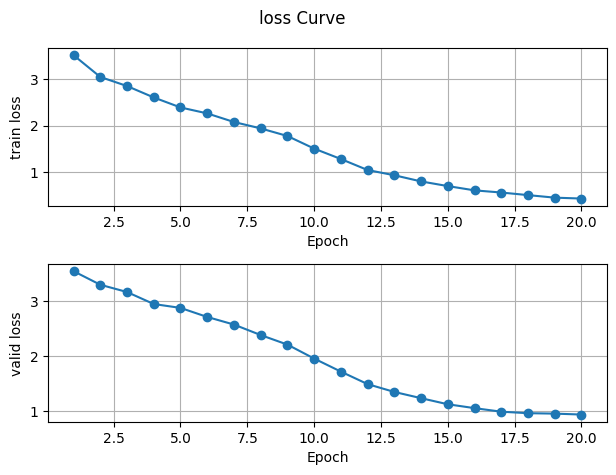

In [56]:
# 결과 시각화

plot_loss_curve(loss_history, metric="loss", overlap=False)

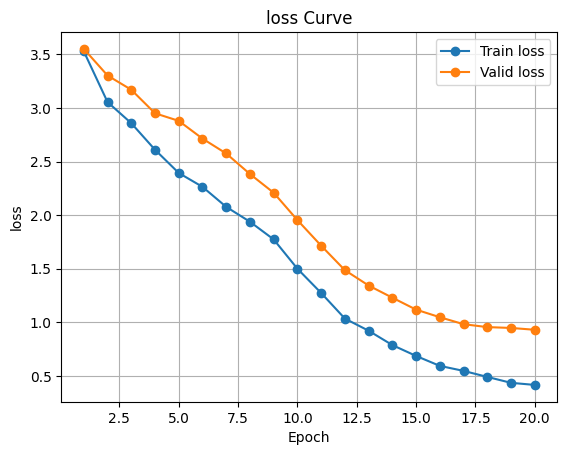

In [57]:
plot_loss_curve(loss_history, metric="loss", overlap=True)

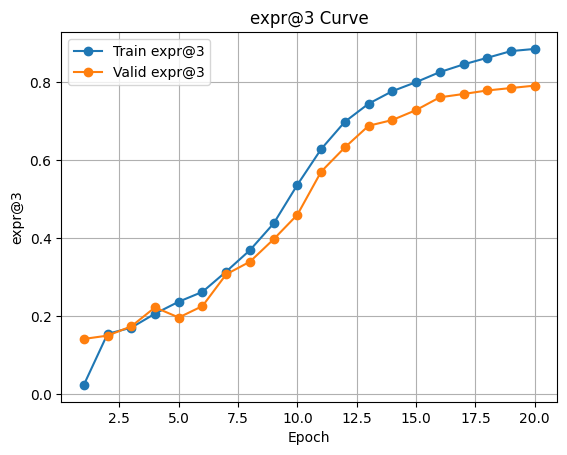

In [58]:
plot_loss_curve(loss_history, metric="expr@3", overlap=True)

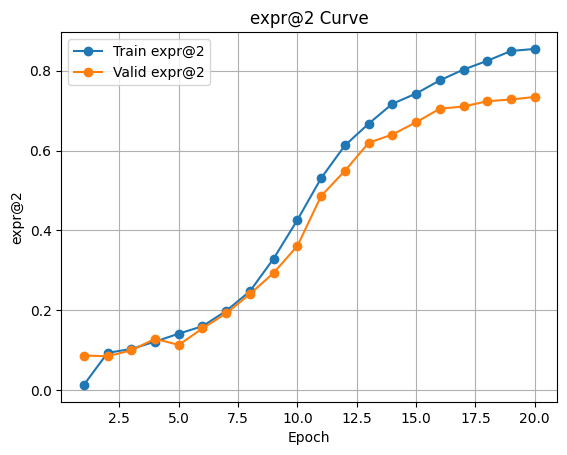

In [59]:
plot_loss_curve(loss_history, metric="expr@2", overlap=True)

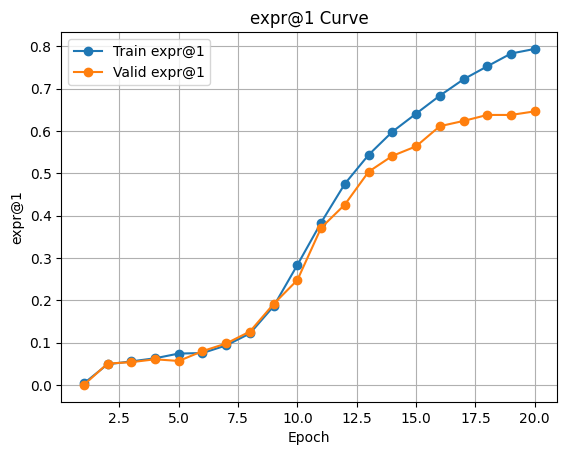

In [60]:
plot_loss_curve(loss_history, metric="expr@1", overlap=True)

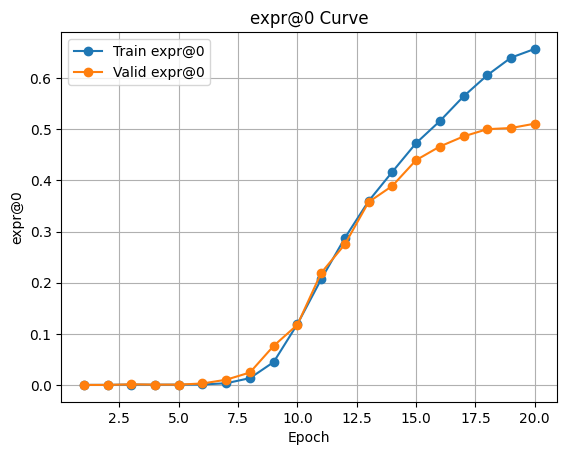

In [61]:
plot_loss_curve(loss_history, metric="expr@0", overlap=True)

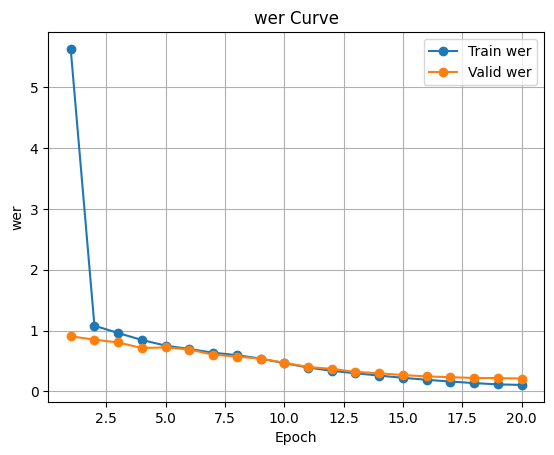

In [62]:
plot_loss_curve(loss_history, metric="wer", overlap=True)

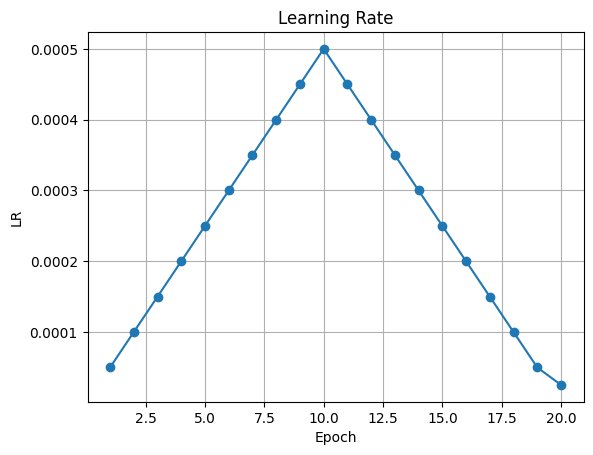

In [63]:
train = loss_history["Train"]

epochs = []
lr = []
for i, history in enumerate(train):
    lr_list = history["lr"]
    epochs.append(i+1)
    lr.append(lr_list[0])

plt.plot(epochs, lr, marker='o')
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.grid(True)
plt.title("Learning Rate")
plt.show()

# Test
- todo: 지금 저장하는 expr은 배치별 평균값이므로 실제 논문에서 언급되는, 다른 모델과 비교하기 위한 expr 척도로는 활용 불가능함 -> 평균 expr이 아니라, 전체 테스트 데이터에 대한 exact match를 count해서 데이터셋 크기로 나눠서 비교할 수 있게 수정해야함

In [64]:
criterion = nn.CrossEntropyLoss(ignore_index=CFG["pad_idx"])

def test(model, test_loader, criterion, device="cuda"):

    eos_idx = CFG["eos_idx"]
    model.eval()

    total_loss = 0.0
    total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
    total_wer = 0.0
    num_batches = 0

    loop = tqdm(test_loader, leave=True)

    for i, batch in enumerate(loop):
        loop.set_description(f"[Test] batch:{i}/{len(test_loader)}")

        imgs = batch["image"].to(device)
        labels = batch["formula"].to(device)

        pred = model(imgs, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
        labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

        loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
        pred_tokens = pred.argmax(dim=-1)              # (B,T-1,V) -> (B,T-1)

        expr_0 = float(exprate_k(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx))
        expr_1 = float(exprate_k(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx))
        expr_2 = float(exprate_k(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx))
        expr_3 = float(exprate_k(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx))
        wer = float(WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx))

        total_loss += float(loss.item())
        total_expr_0 += expr_0
        total_expr_1 += expr_1
        total_expr_2 += expr_2
        total_expr_3 += expr_3
        total_wer += wer
        num_batches += 1

        loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer)

    avg_loss = total_loss / num_batches
    avg_expr_0 = total_expr_0 / num_batches
    avg_expr_1 = total_expr_1 / num_batches
    avg_expr_2 = total_expr_2 / num_batches
    avg_expr_3 = total_expr_3 / num_batches
    avg_wer = total_wer / num_batches

    return avg_loss, avg_expr_0, avg_expr_1, avg_expr_2, avg_expr_3, avg_wer

In [65]:
# best_model.pth 가져오기

model = ASTER().to(DEVICE)
model.load_state_dict(torch.load(CFG["paths"]["best_ckpt"])["model"])

<All keys matched successfully>

In [66]:
# 테스트 및 테스트 결과 구글스프레드시트에 저장

from tqdm import tqdm

test_loaders = [crohme_testloader_2014, crohme_testloader_2016, crohme_testloader_2019,
                cropme_testloader_2014, cropme_testloader_2016, cropme_testloader_2019,
                im2latex_hme_testloader, im2latex_pme_testloader]

test_dataset_names = ["CROHME_2014", "CROHME_2016", "CROHME_2019", "CROPME_2014", "CROPME_2016", "CROPME_2019", "IM2LATEX_HME", "IM2LATEX_PME"]

val_dict = {"loss": [],
            "expr@0": [],
            "expr@1": [],
            "expr@2": [],
            "expr@3": [],
            "wer": []}

for i, test_loader in enumerate(test_loaders):
    test_dataset_name = test_dataset_names[i]
    print(test_dataset_name)

    loss, expr0, expr1, expr2, expr3, wer = test(model, test_loader, criterion)
    val_dict["loss"].append(loss)
    val_dict["expr@0"].append(expr0)
    val_dict["expr@1"].append(expr1)
    val_dict["expr@2"].append(expr2)
    val_dict["expr@3"].append(expr3)
    val_dict["wer"].append(wer)


save_test_result(CFG["experiment_name"], val_dict)

CROHME_2014


[Test] batch:985/986: 100%|██████████| 986/986 [03:20<00:00,  4.92it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=3.47, wer=0.725]


CROHME_2016


[Test] batch:1146/1147: 100%|██████████| 1147/1147 [03:37<00:00,  5.28it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=4.48, wer=0.611]


CROHME_2019


...

[Test] batch:1198/1199: 100%|██████████| 1199/1199 [04:20<00:00,  4.61it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=4.73, wer=0.744]


IM2LATEX_HME


[Test] batch:945/946: 100%|██████████| 946/946 [03:02<00:00,  5.19it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=3.98, wer=0.636]


IM2LATEX_PME


[Test] batch:945/946: 100%|██████████| 946/946 [03:05<00:00,  5.11it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=5.39, wer=0.879]


# Prediction 샘플 시각화

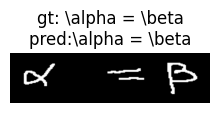

In [67]:
import numpy as np

batch = next(iter(trainloader))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

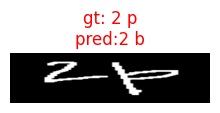

In [68]:
import numpy as np

batch = next(iter(crohme_testloader_2014))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

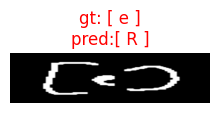

In [69]:
import numpy as np

batch = next(iter(crohme_testloader_2016))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

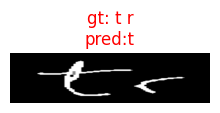

In [70]:
import numpy as np

batch = next(iter(crohme_testloader_2019))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

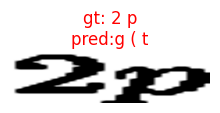

In [71]:
import numpy as np

batch = next(iter(cropme_testloader_2014))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

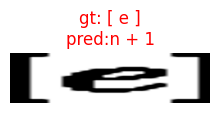

In [72]:
import numpy as np

batch = next(iter(cropme_testloader_2016))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

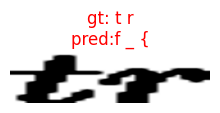

In [73]:
import numpy as np

batch = next(iter(cropme_testloader_2019))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

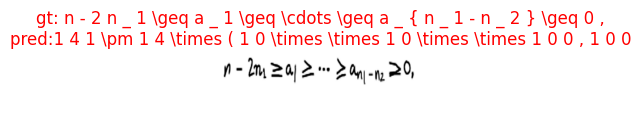

In [74]:
import numpy as np

batch = next(iter(im2latex_hme_testloader))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

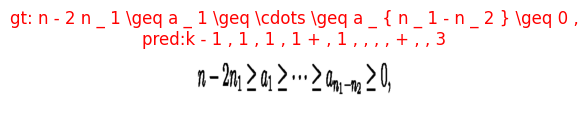

In [75]:
import numpy as np

batch = next(iter(im2latex_pme_testloader))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)